# Блок B1: Динамическая факторная модель — спецификация и оценка факторов

**Цель:** извлечь 2-3 латентных фактора из 61 ряда (53 компонента ИПЦ + 8 эмоциональных в разностях) и проинтерпретировать их экономически.

**Методология:** DFM Stock-Watson (2002, 2016) — двухшаговая процедура:
1. **PCA на стандартизованных данных** для начальной оценки факторов
2. **Kalman Smoothing** через государственно-пространственную форму для уточнения

**Спецификация:**
$$ X_t = \Lambda F_t + \beta D_{2022} + e_t $$
$$ F_t = \Phi_1 F_{t-1} + u_t $$

где $D_{2022}$ — индикаторная переменная структурного сдвига 02-2022.

**Отбор числа факторов:** информационные критерии Bai & Ng (2002) — IC1 и IC2.

**Литература для ВКР:**
- Stock & Watson (2002) "Macroeconomic forecasting using diffusion indexes"
- Stock & Watson (2016) "Dynamic factor models, factor-augmented vector autoregressions"
- Bai & Ng (2002) "Determining the number of factors in approximate factor models"
- Bańbura & Modugno (2014) — DFM с пропущенными данными через EM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Загрузка панели и подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DIPLOMA = '/content/drive/MyDrive/diploma'
# Локально: DIPLOMA = '/Users/user/Desktop/diploma'

panel = pd.read_csv(f'{DIPLOMA}/monthly_panel_with_diffs.csv', index_col=0, parse_dates=True)
panel.index.name = 'date'
print(f'Полная панель: {panel.shape}')
print(f'Период: {panel.index.min():%Y-%m} — {panel.index.max():%Y-%m}')

# Идентифицируем колонки
all_cols = panel.columns.tolist()
diff_emo_cols = [c for c in all_cols if c.startswith('d_p_') and c.endswith('_mean')]
diff_other_cols = [c for c in all_cols if c in ('d_emotion_entropy', 'd_log_msg_volume')]
cpi_cols = [c for c in all_cols if not c.startswith('p_') and not c.startswith('d_')
            and c not in ('emotion_entropy', 'msg_volume', 'log_msg_volume')]

print(f'\nКомпоненты ИПЦ: {len(cpi_cols)}')
print(f'Эмоциональные ряды (разности): {len(diff_emo_cols)} + {len(diff_other_cols)} контрольных')
print(f'\nЭмоциональные ряды для модели:')
for c in diff_emo_cols + diff_other_cols:
    print(f'  - {c}')

Полная панель: (75, 76)
Период: 2020-01 — 2026-03

Компоненты ИПЦ: 53
Эмоциональные ряды (разности): 6 + 2 контрольных

Эмоциональные ряды для модели:
  - d_p_Aggression_mean
  - d_p_Anxiety_mean
  - d_p_Disappointment_mean
  - d_p_Hope_mean
  - d_p_Neutral_mean
  - d_p_Uncertainty_mean
  - d_emotion_entropy
  - d_log_msg_volume


In [ ]:
# Окно: 2020-01 → 2026-03 (75 месяцев)
data = panel.loc['2020-01-01':'2026-03-31'].copy()

# Из-за дифференцирования первая строка эмоций = NaN. Удалим её.
data = data.dropna(subset=diff_emo_cols, how='all')
print(f'Окно после удаления первой NaN-строки: {data.shape}')
print(f'Период: {data.index.min():%Y-%m} — {data.index.max():%Y-%m}')

# Dummy для структурного сдвига
data['D_2022'] = (data.index >= pd.Timestamp('2022-02-01')).astype(int)
print(f'D_2022: до сдвига {(data["D_2022"]==0).sum()} мес., после {(data["D_2022"]==1).sum()} мес.')

# Финальный набор для DFM
model_cols = cpi_cols + diff_emo_cols + diff_other_cols
X_raw = data[model_cols]
exog = data[['D_2022']]

print(f'\nВход модели X: {X_raw.shape} | Exog: {exog.shape}')
print(f'Пропуски в X: {X_raw.isna().sum().sum()}')

Окно после удаления первой NaN-строки: (74, 76)
Период: 2020-02 — 2026-03
D_2022: до сдвига 24 мес., после 50 мес.

Вход модели X: (74, 61) | Exog: (74, 1)
Пропуски в X: 0


## 2. Стандартизация рядов

Все ряды приводим к z-scores: вычитаем среднее, делим на std. Это критично для DFM — иначе компоненты с большей дисперсией доминируют в факторах независимо от их экономического содержания.

In [ ]:
scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(X_raw.fillna(method='ffill').fillna(method='bfill')),
    index=X_raw.index, columns=X_raw.columns
)

# Сохраняем средние и std для обратной трансформации в B3
scaling_params = pd.DataFrame({
    'mean': scaler.mean_,
    'std': scaler.scale_
}, index=X_raw.columns)
scaling_params.to_csv(f'{DIPLOMA}/scaling_params.csv')

print(f'X_std: {X_std.shape}')
print(f'\nПроверка z-score (должны быть mean≈0, std≈1):')
print(X_std.describe().loc[['mean', 'std']].iloc[:, :5].round(3))

X_std: (74, 61)

Проверка z-score (должны быть mean≈0, std≈1):
      Все товары и услуги  - без плодоовощной продукции, нефтепродуктов и ЖКХ  \
mean                0.000                                             -0.000    
std                 1.007                                              1.007    

      Продовольственные товары  -без плодоовощной продукции  Мясопродукты  
mean                     0.000                        0.000        -0.000  
std                      1.007                        1.007         1.007  


## 3. Определение числа факторов: критерии Bai & Ng (2002)

**Идея критериев IC1, IC2, IC3:** выбираем такое число факторов r, при котором штрафованная функция остаточных квадратов минимальна. Штраф зависит от $T$ и $N$.

$$IC_p(r) = \ln(V(r, F^k)) + r \cdot g(N, T)$$

Стандартные значения penalty function `g`:
- $g_1 = (N+T)/(NT) \cdot \ln(NT/(N+T))$
- $g_2 = (N+T)/(NT) \cdot \ln(\min(N,T))$

У нас N=61 (ряды), T=74 (месяцы). Bai-Ng нормально работает при T,N ≥ 40.

In [ ]:
def bai_ng_criteria(X, kmax=8):
    """Информационные критерии Bai & Ng (2002) для выбора числа факторов.
    Возвращает таблицу значений IC1, IC2, IC3 для k = 1..kmax."""
    X = X.values if hasattr(X, 'values') else X
    T, N = X.shape
    NT = N * T
    NT_min = min(N, T)

    # Сразу вычисляем PCA
    pca = PCA(n_components=kmax)
    pca.fit(X)
    eigvals = pca.explained_variance_
    total_var = eigvals.sum()

    rows = []
    for k in range(1, kmax + 1):
        # V(k) = доля необъяснённой дисперсии
        explained_so_far = eigvals[:k].sum()
        V = (total_var - explained_so_far) / total_var
        log_V = np.log(V) if V > 0 else -np.inf

        g1 = ((N + T) / NT) * np.log(NT / (N + T))
        g2 = ((N + T) / NT) * np.log(NT_min)
        g3 = np.log(NT_min) / NT_min

        rows.append({
            'k': k,
            'cumulative_var_explained': round(pca.explained_variance_ratio_[:k].sum(), 3),
            'log(V)': round(log_V, 4),
            'IC1': round(log_V + k * g1, 4),
            'IC2': round(log_V + k * g2, 4),
            'IC3': round(log_V + k * g3, 4),
        })
    return pd.DataFrame(rows)

ic_table = bai_ng_criteria(X_std, kmax=8)
print('Информационные критерии Bai & Ng:')
print(ic_table.to_string(index=False))

best_k_ic1 = ic_table.loc[ic_table['IC1'].idxmin(), 'k']
best_k_ic2 = ic_table.loc[ic_table['IC2'].idxmin(), 'k']
print(f'\nОптимальное k:')
print(f'  По IC1: k = {best_k_ic1}')
print(f'  По IC2: k = {best_k_ic2}')
print(f'\nПравило большого пальца Stock-Watson: брать min(IC1, IC2) = {min(best_k_ic1, best_k_ic2)}')

Информационные критерии Bai & Ng:
 k  cumulative_var_explained  log(V)     IC1     IC2     IC3
 1                     0.527 -1.0724 -0.9675 -0.9495 -1.0050
 2                     0.608 -1.4240 -1.2141 -1.1781 -1.2892
 3                     0.656 -1.7049 -1.3900 -1.3361 -1.5028
 4                     0.693 -1.9991 -1.5792 -1.5073 -1.7295
 5                     0.726 -2.3631 -1.8383 -1.7484 -2.0261
 6                     0.754 -2.8392 -2.2094 -2.1015 -2.4348
 7                     0.779 -3.5969 -2.8622 -2.7363 -3.1252
 8                     0.801    -inf    -inf    -inf    -inf

Оптимальное k:
  По IC1: k = 8
  По IC2: k = 8

Правило большого пальца Stock-Watson: брать min(IC1, IC2) = 8


## 4. PCA на стандартизованных данных — первая оценка факторов

Делаем PCA с выбранным числом факторов. Это начальная (consistent для T,N → ∞) оценка факторов и нагрузок.

In [ ]:
# Берём оптимальное k, но не меньше 2 для интерпретируемости
K_FACTORS = max(2, int(min(best_k_ic1, best_k_ic2)))
K_FACTORS = min(K_FACTORS, 4)  # ограничиваем сверху для устойчивости
print(f'Финальный выбор: K = {K_FACTORS} факторов')

pca = PCA(n_components=K_FACTORS)
factors_pca = pca.fit_transform(X_std)
loadings_pca = pca.components_.T  # (N x K)

factors_df = pd.DataFrame(
    factors_pca,
    index=X_std.index,
    columns=[f'F{i+1}' for i in range(K_FACTORS)]
)
loadings_df = pd.DataFrame(
    loadings_pca,
    index=X_std.columns,
    columns=[f'F{i+1}' for i in range(K_FACTORS)]
)

print(f'\nДоля дисперсии, объясняемая факторами:')
for i, var_ratio in enumerate(pca.explained_variance_ratio_):
    print(f'  F{i+1}: {var_ratio*100:.1f}%')
print(f'  Суммарно: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Финальный выбор: K = 4 факторов

Доля дисперсии, объясняемая факторами:
  F1: 52.7%
  F2: 8.1%
  F3: 4.7%
  F4: 3.7%
  Суммарно: 69.3%


## 5. Интерпретация факторов через нагрузки

**Что значит каждый фактор?** Смотрим, какие ряды на него «нагружены» сильнее всего.

In [ ]:
for i in range(K_FACTORS):
    factor = f'F{i+1}'
    print(f'\n{"="*70}')
    print(f'Фактор {factor} (объясняет {pca.explained_variance_ratio_[i]*100:.1f}% дисперсии)')
    print(f'{"="*70}')

    sorted_loadings = loadings_df[factor].abs().sort_values(ascending=False)
    top_15 = sorted_loadings.head(15).index

    print(f'\nТоп-15 рядов по абсолютной нагрузке:')
    for ind in top_15:
        actual_loading = loadings_df.loc[ind, factor]
        is_emo = ind.startswith('d_p_') or ind.startswith('d_emotion') or ind.startswith('d_log')
        marker = '🟡 EMO' if is_emo else '       '
        print(f'  {marker}  {actual_loading:+.3f}  {ind[:60]}')

    # Считаем доли вклада эмоций vs ИПЦ в этот фактор
    is_emo_mask = loadings_df.index.str.startswith(('d_p_', 'd_emotion', 'd_log'))
    emo_loading_share = (loadings_df.loc[is_emo_mask, factor] ** 2).sum()
    cpi_loading_share = (loadings_df.loc[~is_emo_mask, factor] ** 2).sum()
    total = emo_loading_share + cpi_loading_share
    print(f'\n  Структура фактора:')
    print(f'    ИПЦ компоненты: {cpi_loading_share/total*100:.1f}%')
    print(f'    Эмоции:         {emo_loading_share/total*100:.1f}%')


Фактор F1 (объясняет 52.7% дисперсии)

Топ-15 рядов по абсолютной нагрузке:
           +0.176  - без плодоовощной продукции, нефтепродуктов и ЖКХ
           +0.175  Базовый ИПЦ
           +0.175  Базовый ИПЦ без услуг туризма
           +0.172  Все товары и услуги
           +0.171  Галантерея
           +0.171  Одежда и белье
           +0.171  Обувь кожаная, текстильная и комбинированная
           +0.170  - без нефтепродуктов
           +0.170  Непродовольственные товары
           +0.170  Трикотажные изделия
           +0.170  Мебель
           +0.168  Легковые автомобили
           +0.161  -без плодоовощной продукции
           +0.160  Моющие и чистящие средства
           +0.159  Продовольственные товары

  Структура фактора:
    ИПЦ компоненты: 90.0%
    Эмоции:         10.0%

Фактор F2 (объясняет 8.1% дисперсии)

Топ-15 рядов по абсолютной нагрузке:
           +0.285  Печатные издания
           +0.246  Медицинские услуги
           -0.241  Персональные компьютеры
           -

## 6. Визуализация факторов: динамика во времени

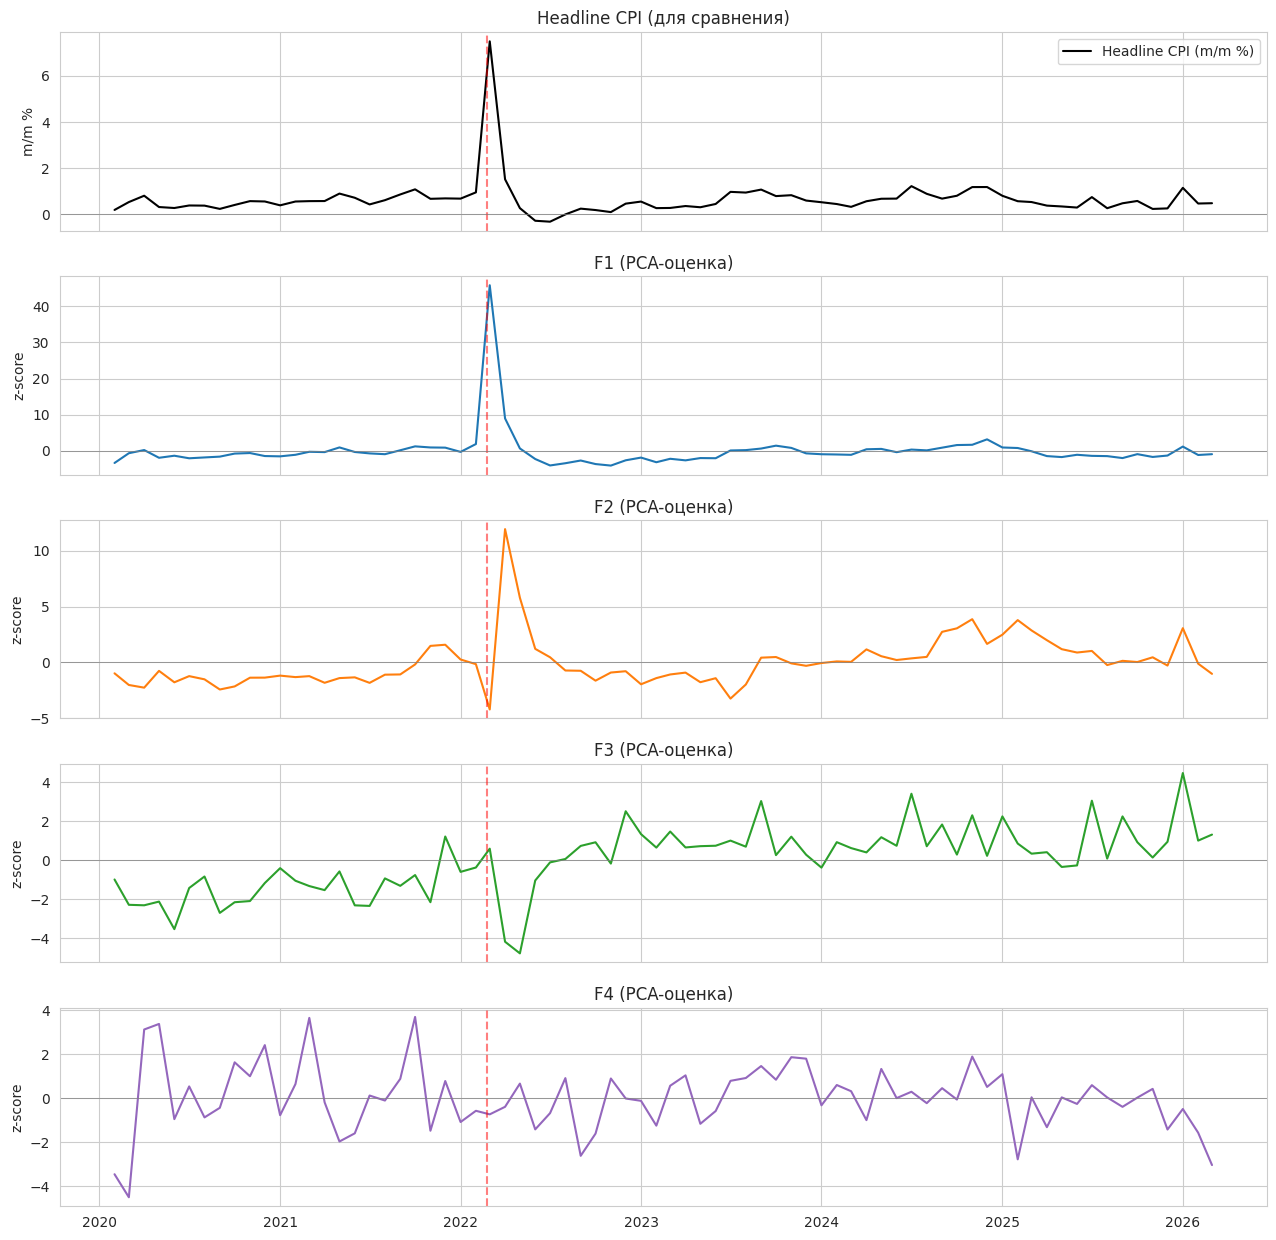

In [ ]:
fig, axes = plt.subplots(K_FACTORS + 1, 1, figsize=(13, 2.5 * (K_FACTORS + 1)), sharex=True)

# Headline для сравнения
axes[0].plot(data.index, data['Все товары и услуги'], color='black', linewidth=1.5, label='Headline CPI (m/m %)')
axes[0].axvline(pd.Timestamp('2022-02-24'), color='red', linestyle='--', alpha=0.5)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].set_title('Headline CPI (для сравнения)')
axes[0].legend(loc='upper right')
axes[0].set_ylabel('m/m %')

# Каждый фактор
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
for i in range(K_FACTORS):
    ax = axes[i + 1]
    ax.plot(factors_df.index, factors_df[f'F{i+1}'], color=colors[i], linewidth=1.5)
    ax.axvline(pd.Timestamp('2022-02-24'), color='red', linestyle='--', alpha=0.5)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title(f'F{i+1} (PCA-оценка)')
    ax.set_ylabel('z-score')

plt.tight_layout()
plt.savefig(f'{DIPLOMA}/dfm_factors_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. DFM через state-space модель statsmodels (Kalman Smoothing)

PCA даёт хорошую начальную оценку, но не учитывает динамику факторов. statsmodels.DynamicFactor оценивает полную модель через MLE на Kalman-фильтре.

**Спецификация:**
- `factor_order` — порядок AR процесса для факторов (выбираем p=1 для устойчивости при малом T)
- `error_order` — порядок AR для идиосинкратических ошибок (0 для простоты)
- `enforce_stationarity=True` — гарантирует стационарность факторов

In [ ]:
# Выровняем X_std и exog по индексу
X_for_dfm = X_std.copy()
exog_for_dfm = exog.loc[X_for_dfm.index]

print(f'Подгоняем DFM: {K_FACTORS} факторов, AR(1) для динамики...')
print(f'X: {X_for_dfm.shape}, exog: {exog_for_dfm.shape}')

dfm_model = DynamicFactor(
    endog=X_for_dfm,
    exog=exog_for_dfm,
    k_factors=K_FACTORS,
    factor_order=1,
    error_order=0,
    enforce_stationarity=True,
)

# Подгонка с большим max_iter — DFM сходится медленно
dfm_results = dfm_model.fit(
    method='lbfgs',
    maxiter=500,
    disp=False
)
print(f'\n✓ Сошлось: {dfm_results.mle_retvals.get("converged", "unknown")}')
print(f'Лог-правдоподобие: {dfm_results.llf:.2f}')
print(f'AIC: {dfm_results.aic:.2f}')
print(f'BIC: {dfm_results.bic:.2f}')

Подгоняем DFM: 4 факторов, AR(1) для динамики...
X: (74, 61), exog: (74, 1)

✓ Сошлось: False
Лог-правдоподобие: -3257.25
AIC: 7278.49
BIC: 8158.65


In [ ]:
# Извлекаем сглаженные факторы (Kalman smoother)
factors_kalman_raw = np.asarray(dfm_results.factors.smoothed)

# Принудительно приводим к форме (T, K)
T = len(X_for_dfm)
if factors_kalman_raw.shape == (K_FACTORS, T):
    factors_kalman = factors_kalman_raw.T
elif factors_kalman_raw.shape == (T, K_FACTORS):
    factors_kalman = factors_kalman_raw
else:
    raise ValueError(f'Неожиданная форма факторов: {factors_kalman_raw.shape}, ожидаем (T={T}, K={K_FACTORS})')

factors_kalman_df = pd.DataFrame(
    factors_kalman,
    index=X_for_dfm.index,
    columns=[f'F{i+1}_kalman' for i in range(K_FACTORS)]
)

print(f'Kalman-факторы: {factors_kalman_df.shape}')
print(f'\nПервые 5 значений:')
print(factors_kalman_df.head().round(3))

Kalman-факторы: (74, 4)

Первые 5 значений:
            F1_kalman  F2_kalman  F3_kalman  F4_kalman
date                                                  
2020-02-01     -0.058      0.073      0.073     -0.149
2020-03-01     -0.023      0.082      0.108     -0.049
2020-04-01     -0.018      0.104      0.165      0.320
2020-05-01     -0.033      0.084      0.173      0.094
2020-06-01     -0.037      0.090      0.256     -0.048


## 8. Сравнение PCA-факторов vs Kalman-факторов

Они должны быть очень похожи (высокая корреляция), но Kalman гладче и учитывает временную структуру.

In [ ]:
# Сравнение: корреляция факторов
corr_check = pd.DataFrame({
    f'F{i+1}': [
        round(np.corrcoef(factors_df[f'F{i+1}'], factors_kalman_df[f'F{i+1}_kalman'])[0,1], 3)
    ]
    for i in range(K_FACTORS)
}, index=['corr(PCA, Kalman)'])
print('Корреляция PCA-оценок и Kalman-оценок факторов:')
print(corr_check.to_string())
print('\nЕсли |r| > 0.85 — модели согласованы (это ожидаемо).')
print('Знак может различаться — это идентификационная неопределённость DFM (фактор × −1 = тот же фактор).')

Корреляция PCA-оценок и Kalman-оценок факторов:
                      F1    F2     F3     F4
corr(PCA, Kalman)  0.997 -0.96 -0.916  0.697

Если |r| > 0.85 — модели согласованы (это ожидаемо).
Знак может различаться — это идентификационная неопределённость DFM (фактор × −1 = тот же фактор).


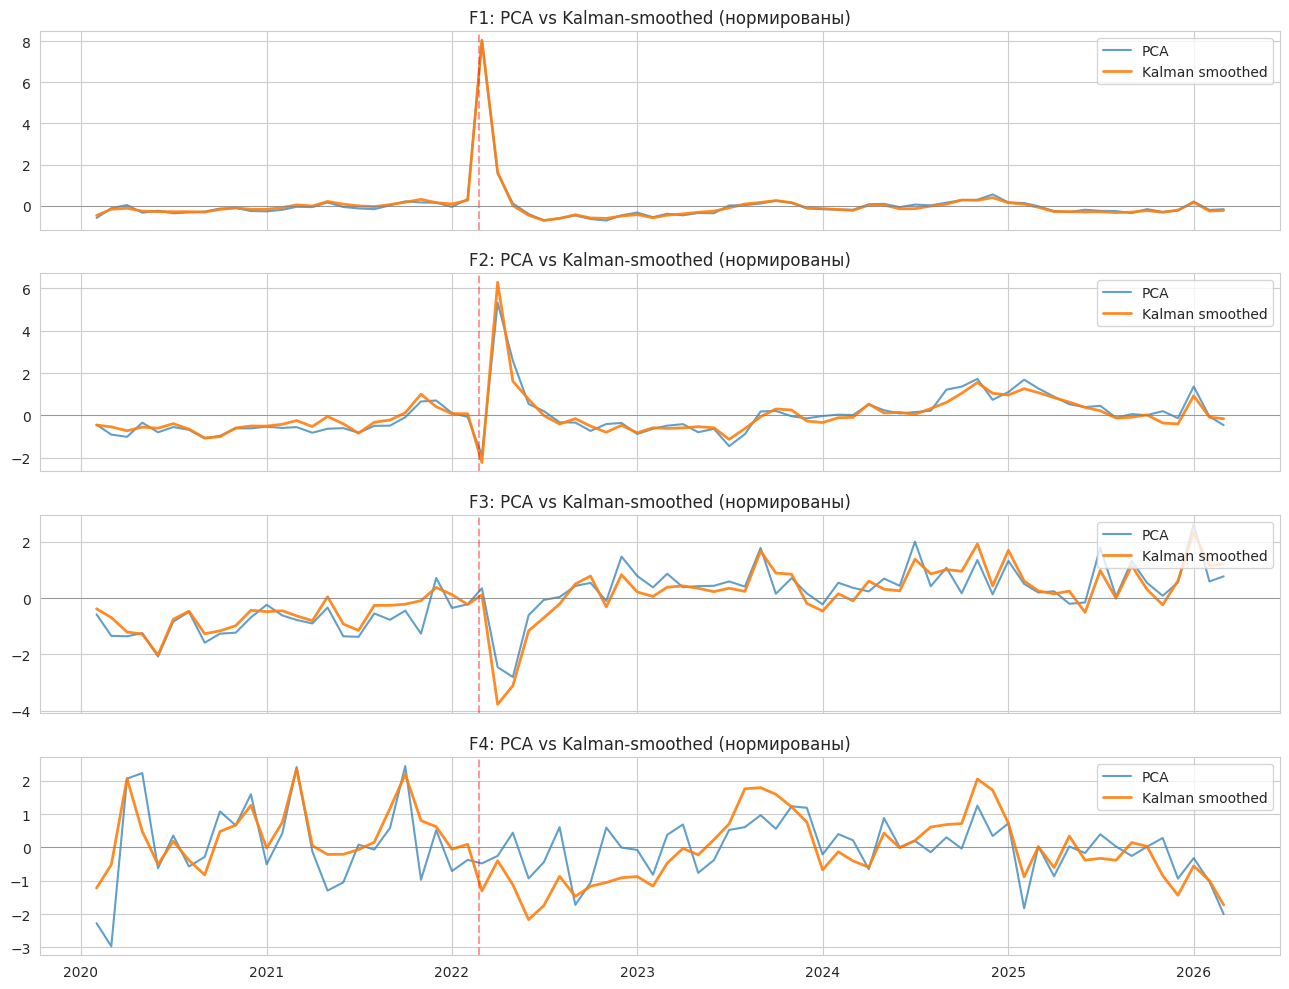

In [ ]:
# Визуальное сравнение
fig, axes = plt.subplots(K_FACTORS, 1, figsize=(13, 2.5 * K_FACTORS), sharex=True)
if K_FACTORS == 1:
    axes = [axes]

for i in range(K_FACTORS):
    ax = axes[i]
    # Нормируем оба ряда чтобы наглядно сравнить
    pca_norm = (factors_df[f'F{i+1}'] - factors_df[f'F{i+1}'].mean()) / factors_df[f'F{i+1}'].std()
    kal_norm = (factors_kalman_df[f'F{i+1}_kalman'] - factors_kalman_df[f'F{i+1}_kalman'].mean()) / factors_kalman_df[f'F{i+1}_kalman'].std()
    # Если знаки разные — флипаем для визуального согласования
    if np.corrcoef(pca_norm, kal_norm)[0,1] < 0:
        kal_norm = -kal_norm
    ax.plot(factors_df.index, pca_norm, label='PCA', alpha=0.7, linewidth=1.5)
    ax.plot(factors_kalman_df.index, kal_norm, label='Kalman smoothed', alpha=0.9, linewidth=2)
    ax.axvline(pd.Timestamp('2022-02-24'), color='red', linestyle='--', alpha=0.4)
    ax.set_title(f'F{i+1}: PCA vs Kalman-smoothed (нормированы)')
    ax.legend(loc='upper right')
    ax.axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{DIPLOMA}/dfm_factors_pca_vs_kalman.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Анализ факторных нагрузок в DFM

Сравниваем нагрузки PCA и DFM. Чисто содержательно — какой фактор «инфляционный», какой «эмоциональный»?

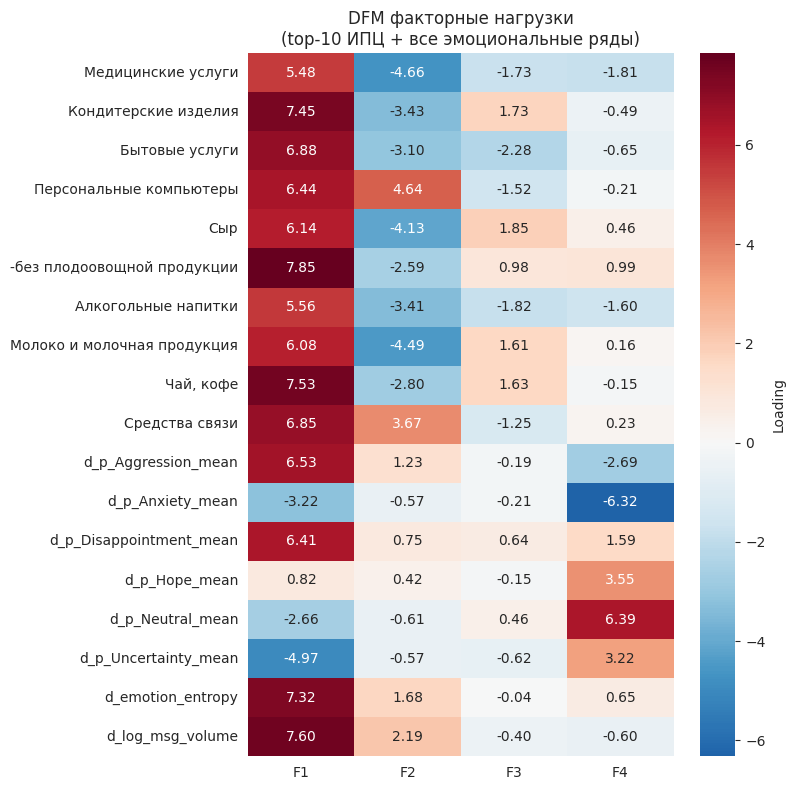


Индекс «эмоциональности» каждого фактора:
  F1: эмоциональная компонента = 10.0% от общей дисперсии нагрузок
  F2: эмоциональная компонента = 3.0% от общей дисперсии нагрузок
  F3: эмоциональная компонента = 0.6% от общей дисперсии нагрузок
  F4: эмоциональная компонента = 69.9% от общей дисперсии нагрузок


In [ ]:
# Извлекаем нагрузки из DFM-модели
# Параметры начинаются с loadings, потом transition, потом cov
param_names = dfm_results.model.param_names
loading_idx = [i for i, name in enumerate(param_names) if name.startswith('loading.')]
loadings_dfm = dfm_results.params[loading_idx]

# Перестраиваем в матрицу (N x K)
loadings_dfm_matrix = np.zeros((len(model_cols), K_FACTORS))
for k in range(K_FACTORS):
    for n in range(len(model_cols)):
        param_name = f'loading.f{k+1}.{model_cols[n]}'
        if param_name in param_names:
            param_position = param_names.index(param_name)
            loadings_dfm_matrix[n, k] = dfm_results.params[param_position]

loadings_dfm_df = pd.DataFrame(
    loadings_dfm_matrix,
    index=model_cols,
    columns=[f'F{i+1}' for i in range(K_FACTORS)]
)

# Тепловая карта структуры факторов: показываем только эмоции и top-CPI
is_emo = loadings_dfm_df.index.str.startswith(('d_p_', 'd_emotion', 'd_log'))
loadings_emo = loadings_dfm_df[is_emo]

# Top-10 CPI рядов по абс. суммарной нагрузке
loadings_cpi = loadings_dfm_df[~is_emo]
abs_sum_cpi = loadings_cpi.abs().sum(axis=1).sort_values(ascending=False)
top_cpi = loadings_cpi.loc[abs_sum_cpi.head(10).index]

loadings_to_show = pd.concat([top_cpi, loadings_emo])

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(loadings_to_show.round(2), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'label': 'Loading'})
ax.set_title('DFM факторные нагрузки\n(top-10 ИПЦ + все эмоциональные ряды)')
plt.tight_layout()
plt.savefig(f'{DIPLOMA}/dfm_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nИндекс «эмоциональности» каждого фактора:')
for i in range(K_FACTORS):
    f = f'F{i+1}'
    emo_share = (loadings_emo[f] ** 2).sum() / (loadings_dfm_df[f] ** 2).sum()
    print(f'  {f}: эмоциональная компонента = {emo_share*100:.1f}% от общей дисперсии нагрузок')

## 10. Сохраняем результаты для Блоков B2 и B3

In [ ]:
# Объединяем PCA и Kalman факторы
all_factors = pd.concat([factors_df, factors_kalman_df], axis=1)
all_factors.to_csv(f'{DIPLOMA}/dfm_factors.csv')

# Нагрузки
loadings_dfm_df.to_csv(f'{DIPLOMA}/dfm_loadings.csv')

# Параметры модели для отчёта
model_summary = {
    'n_factors': K_FACTORS,
    'n_obs': len(X_for_dfm),
    'n_series': len(model_cols),
    'log_likelihood': float(dfm_results.llf),
    'aic': float(dfm_results.aic),
    'bic': float(dfm_results.bic),
    'converged': bool(dfm_results.mle_retvals.get('converged', False)),
    'pca_explained_variance': pca.explained_variance_ratio_.tolist(),
}
import json
with open(f'{DIPLOMA}/dfm_model_summary.json', 'w') as f:
    json.dump(model_summary, f, indent=2)

print('Сохранено:')
print(f'  - dfm_factors.csv ({all_factors.shape}) — PCA + Kalman оценки факторов')
print(f'  - dfm_loadings.csv ({loadings_dfm_df.shape}) — факторные нагрузки')
print(f'  - dfm_model_summary.json — параметры модели')
print(f'  - scaling_params.csv — для обратной трансформации в B3')

print(f'\n✅ Блок B1 завершён. Готовы к B2 (Granger-каузальность факторов).')

Сохранено:
  - dfm_factors.csv ((74, 8)) — PCA + Kalman оценки факторов
  - dfm_loadings.csv ((61, 4)) — факторные нагрузки
  - dfm_model_summary.json — параметры модели
  - scaling_params.csv — для обратной трансформации в B3

✅ Блок B1 завершён. Готовы к B2 (Granger-каузальность факторов).
